In [1]:
import pandas as pd
import numpy as np
import torch

In [ ]:
from src.data_preprocessing import preprocess_data

data, label_encoder, encoded_labels = preprocess_data(embedding="onehot", removeDuplicates=True)

In [15]:
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [16]:
# Prepare features and labels
X = torch.stack(data["Features_Encoded_Padded"].tolist())  # shape: (N, seq_len, 29)
y = torch.from_numpy(encoded_labels)       # shape: (N, num_classes)

In [17]:
X.size(), y.size()

(torch.Size([18383, 50, 29]), torch.Size([18383, 2]))

In [18]:
# Train/test split (80/20)
N = len(X)
train_size = int(0.8 * N)
test_size = N - train_size
dataset = torch.utils.data.TensorDataset(X, y)
train_dataset, test_dataset = random_split(dataset, [train_size, test_size], generator=torch.Generator().manual_seed(42))

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [19]:
# TCN Model
class TCNBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, dilation=1):
        super().__init__()
        # causal padding = (k - 1) * dilation
        pad = (k - 1) * dilation
        self.conv = nn.Conv1d(in_ch, out_ch, k, padding=pad, dilation=dilation)
        self.act = nn.ReLU()
        self.down = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else None

    def forward(self, x):
        out = self.conv(x)
        out = out[:, :, :-self.conv.padding[0]]  # crop to keep causality
        res = x if self.down is None else self.down(x)
        return self.act(out + res)

class TCN(nn.Module):
    def __init__(self, in_ch, hidden=32, out_ch=1):
        super().__init__()
        self.block1 = TCNBlock(in_ch, hidden, dilation=1)
        self.block2 = TCNBlock(hidden, hidden, dilation=2)
        self.block3 = TCNBlock(hidden, hidden, dilation=4)
        self.head = nn.Conv1d(hidden, out_ch, kernel_size=1)

    def forward(self, x):
        # x input shape: (batch, seq_len, features)
        x = x.permute(0, 2, 1)  # → (batch, features, seq)
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        out = self.head(x)        # (batch, out_ch, seq)
        return out[:, :, -1]      # prediction at last step

In [20]:
num_classes = y.shape[1]
model = TCN(in_ch=29, hidden=32, out_ch=num_classes)

# Loss and optimizer
criterion = nn.BCEWithLogitsLoss() if num_classes > 1 else nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [21]:
from sklearn.metrics import accuracy_score, recall_score, f1_score

def evaluate(model, loader):
    model.eval()
    all_preds, all_targets = [], []

    with torch.no_grad():
        for xb, yb in loader:
            logits = model(xb)
            preds = torch.argmax(logits, dim=1)
            targets = torch.argmax(yb, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(targets.cpu().numpy())

    acc = accuracy_score(all_targets, all_preds)
    recall = recall_score(all_targets, all_preds, pos_label=1)
    f1 = f1_score(all_targets, all_preds, pos_label=1)

    return acc, recall, f1

In [22]:
# Training loop
train_losses = []
val_accs = []
val_recalls = []
val_f1s = []

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    train_loss = 0

    for xb, yb in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    train_loss /= len(train_loader)
    train_losses.append(train_loss)

    val_acc, val_recall, val_f1 = evaluate(model, test_loader)
    val_accs.append(val_acc)
    val_recalls.append(val_recall)
    val_f1s.append(val_f1)

    print(
        f"Epoch {epoch+1} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val Recall: {val_recall:.4f} | "
        f"Val F1: {val_f1:.4f}"
    )

Epoch 1 | Train Loss: 0.3047 | Val Acc: 0.9508 | Val Recall: 0.9860 | Val F1: 0.9689
Epoch 2 | Train Loss: 0.1170 | Val Acc: 0.9674 | Val Recall: 0.9825 | Val F1: 0.9791
Epoch 3 | Train Loss: 0.0913 | Val Acc: 0.9739 | Val Recall: 0.9839 | Val F1: 0.9832
Epoch 4 | Train Loss: 0.0802 | Val Acc: 0.9753 | Val Recall: 0.9874 | Val F1: 0.9842
Epoch 5 | Train Loss: 0.0775 | Val Acc: 0.9753 | Val Recall: 0.9888 | Val F1: 0.9842
Epoch 6 | Train Loss: 0.0751 | Val Acc: 0.9769 | Val Recall: 0.9871 | Val F1: 0.9852
Epoch 7 | Train Loss: 0.0718 | Val Acc: 0.9774 | Val Recall: 0.9860 | Val F1: 0.9855
Epoch 8 | Train Loss: 0.0703 | Val Acc: 0.9780 | Val Recall: 0.9941 | Val F1: 0.9860
Epoch 9 | Train Loss: 0.0705 | Val Acc: 0.9782 | Val Recall: 0.9860 | Val F1: 0.9860
Epoch 10 | Train Loss: 0.0692 | Val Acc: 0.9766 | Val Recall: 0.9881 | Val F1: 0.9850


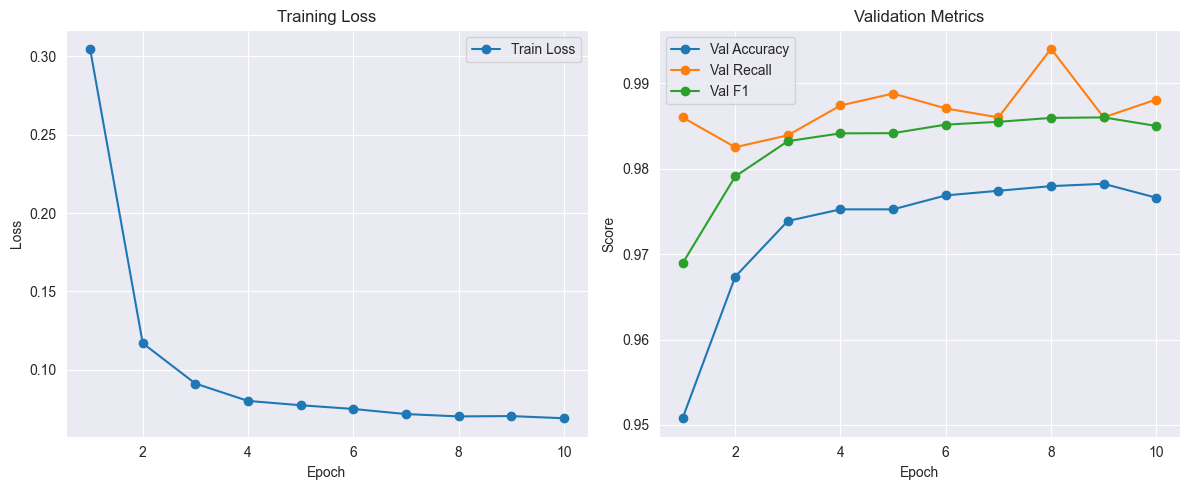

In [23]:
import matplotlib.pyplot as plt

epochs = range(1, len(train_losses)+1)

plt.figure(figsize=(12, 5))

# Loss
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, label='Train Loss', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.grid(True)
plt.legend()

# Validation metrics
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accs, label='Val Accuracy', marker='o')
plt.plot(epochs, val_recalls, label='Val Recall', marker='o')
plt.plot(epochs, val_f1s, label='Val F1', marker='o')
plt.xlabel('Epoch')
plt.ylabel('Score')
plt.title('Validation Metrics')
plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


In [24]:
from sklearn.metrics import classification_report

all_preds = []
all_targets = []
all_scores = []
all_labels = []

model.eval()
with torch.no_grad():
    for xb, yb in test_loader:
        logits = model(xb)
        scores = torch.sigmoid(logits)

        if num_classes > 1:
            # Multi-class/One-hot: use argmax to get class index (0, 1, etc.)
            preds = torch.argmax(logits, dim=1)
            targets = torch.argmax(yb, dim=1)
        else:
            # Binary (single output neuron): threshold at 0
            preds = (logits > 0).float().view(-1)
            targets = yb.view(-1)

        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())
        all_scores.append(scores.cpu())
        all_labels.append(yb.cpu())

Classification Report:
              precision    recall  f1-score   support

        Fail     0.9573    0.9362    0.9467       815
     Success     0.9819    0.9881    0.9850      2862

    accuracy                         0.9766      3677
   macro avg     0.9696    0.9622    0.9658      3677
weighted avg     0.9765    0.9766    0.9765      3677



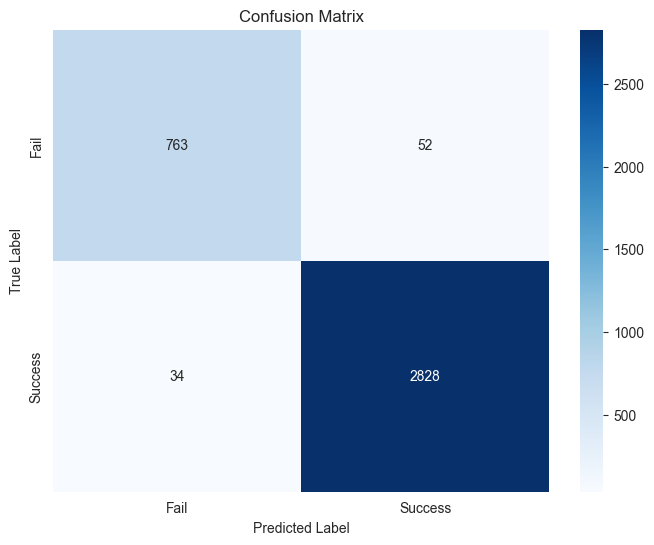

In [25]:
# Get readable class names from the label encoder
class_names = [str(c) for c in label_encoder.categories_[0]]
print("Classification Report:")
print(classification_report(all_targets, all_preds, target_names=class_names, digits=4))

# --- Visual Evaluation: Confusion Matrix ---
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Calculate confusion matrix
cm = confusion_matrix(all_targets, all_preds)

# Plot heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()


In [26]:
from sklearn.metrics import average_precision_score

In [27]:
y_score = torch.cat(all_scores).numpy().ravel()
y_true  = torch.cat(all_labels).numpy().ravel()

pr_auc = average_precision_score(y_true, y_score)

print("PR-AUC:", pr_auc)

PR-AUC: 0.9923458884123527


In [ ]:
torch.save(model.state_dict(), "../../saved_models/tcn_one_hot_encoding.pth")